# 🎬 UK House Prices (2015–2024) — Exploratory Data Analysis and Feature Engineering

Dataset: `swarupsudulaganti/uk-house-price-prediction-dataset-2015-to-2024`


## 0) Environment Setup

In [ ]:
!pip -q install kagglehub==1.0.0 seaborn scikit-learn

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

print("✅ Setup complete")



✅ Setup complete


## 1) Download + Load Data

### Concept
Reproducibility matters. Instead of manually uploading the file, we download from Kaggle using `kagglehub`.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("swarupsudulaganti/uk-house-price-prediction-dataset-2015-to-2024")
print("Dataset path:", path)

csv_files=[]
for root,_,files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root,f))

csv_path = sorted(csv_files)[0]
df_raw = pd.read_csv(csv_path)
print("Loaded:", csv_path)

df_raw.head()

Using Colab cache for faster access to the 'uk-house-price-prediction-dataset-2015-to-2024' dataset.
Dataset path: /kaggle/input/uk-house-price-prediction-dataset-2015-to-2024
Loaded: /kaggle/input/uk-house-price-prediction-dataset-2015-to-2024/UK_House_Price_Prediction_dataset_2015_to_2024.csv


,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
0,735000,2017-08-07,LE17 5AP,D,N,F,CLAYBROOKE COURT,CLAYBROOKE PARVA,LUTTERWORTH,HARBOROUGH,LEICESTERSHIRE
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY,MEDWAY
3,625000,2021-10-13,RH20 3EU,D,N,F,LINFIELD COPSE,THAKEHAM,PULBOROUGH,HORSHAM,WEST SUSSEX
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE,WILTSHIRE


## 2) Baseline Profiling

In [ ]:
row_count = df_raw.shape[0]
print(f"The df_raw DataFrame has {row_count} rows.")

The df_raw DataFrame has 90000 rows.


In [ ]:
col_count = df_raw.shape[1]
print(f"The df_raw DataFrame has {col_count} columns.")

The df_raw DataFrame has 11 columns.


In [ ]:
df_raw.head()

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
0,735000,2017-08-07,LE17 5AP,D,N,F,CLAYBROOKE COURT,CLAYBROOKE PARVA,LUTTERWORTH,HARBOROUGH,LEICESTERSHIRE
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY,MEDWAY
3,625000,2021-10-13,RH20 3EU,D,N,F,LINFIELD COPSE,THAKEHAM,PULBOROUGH,HORSHAM,WEST SUSSEX
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE,WILTSHIRE


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          90000 non-null  int64 
 1   date           90000 non-null  object
 2   postcode       90000 non-null  object
 3   property_type  90000 non-null  object
 4   new_build      90000 non-null  object
 5   freehold       90000 non-null  object
 6   street         90000 non-null  object
 7   locality       90000 non-null  object
 8   town           90000 non-null  object
 9   district       90000 non-null  object
 10  county         90000 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.6+ MB


In [ ]:
df_raw.head()

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
0,735000,2017-08-07,LE17 5AP,D,N,F,CLAYBROOKE COURT,CLAYBROOKE PARVA,LUTTERWORTH,HARBOROUGH,LEICESTERSHIRE
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY,MEDWAY
3,625000,2021-10-13,RH20 3EU,D,N,F,LINFIELD COPSE,THAKEHAM,PULBOROUGH,HORSHAM,WEST SUSSEX
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE,WILTSHIRE


### Check Unique Values - Cardinality

In [ ]:
df_raw.nunique(dropna=False).sort_values(ascending=False).head(20)

,0
postcode,75323
street,43483
locality,10145
price,6111
date,2553
town,958
district,359
county,117
property_type,5
freehold,2


###Data Quality Validation:
- Missing values
- Duplicate records
- Inconsitent formating
- Categoy inconsistencies

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          90000 non-null  int64 
 1   date           90000 non-null  object
 2   postcode       90000 non-null  object
 3   property_type  90000 non-null  object
 4   new_build      90000 non-null  object
 5   freehold       90000 non-null  object
 6   street         90000 non-null  object
 7   locality       90000 non-null  object
 8   town           90000 non-null  object
 9   district       90000 non-null  object
 10  county         90000 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.6+ MB


###Many real datasets encode missing values as strings:

Sometimes missing values are encoded as strings ("", "Unknown", "N/A", "NULL").
We convert them into true NaN so pandas and sklearn can handle them properly.

In [ ]:
MISSING_TOKENS = ["", " ", "NA", "N/A", "NULL", "null", "None", "none", "Unknown", "UNKNOWN", "Not known", "NOT KNOWN"]

obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].replace(MISSING_TOKENS, np.nan)

print("AFTER: Missing values count (top 20):")
df.isna().sum().sort_values(ascending=False).head(20)

AFTER: Missing values count (top 20):


,0
price,0
date,0
postcode,0
property_type,0
new_build,0
freehold,0
street,0
locality,0
town,0
district,0


###Formating
Trailing/leading spaces create fake categories: "London" vs "London ". We strip whitespace across all object columns

In [ ]:
check_cols = ["town","district","county","street"]
print("BEFORE → AFTER unique count comparison")
for col in check_cols:
    before_unique = df[col].nunique(dropna=False)
    after_unique = df[col].astype(str).str.strip().nunique(dropna=False)
    print(f"{col}: BEFORE={before_unique} | AFTER(strip)={after_unique}")

BEFORE → AFTER unique count comparison
town: BEFORE=958 | AFTER(strip)=958
district: BEFORE=359 | AFTER(strip)=359
county: BEFORE=117 | AFTER(strip)=117
street: BEFORE=43483 | AFTER(strip)=43483


### Low Cardinality Variables

In [ ]:
df_raw.nunique(dropna=False).sort_values(ascending=False).head(20)

,0
postcode,75323
street,43483
locality,10145
price,6111
date,2553
town,958
district,359
county,117
property_type,5
freehold,2


### Concept
Categor Normalisation -  Casing inconsistencies create multiple categories: `Detached` vs `DETACHED`.
We normalize low-cardinality categorical features to uppercase and single spacing.


In [ ]:
def normalize_category(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.strip()
             .str.replace(r"\s+", " ", regex=True)
             .str.upper())

low_card = ["property_type","new_build","freehold"]

for col in low_card:
    df[col] = normalize_category(df[col])

print("AFTER normalization")
for col in low_card:
    print("\n===", col, "===")
    display(df[col].value_counts(dropna=False).head(20))


AFTER normalization

=== property_type ===


,count
property_type,
D,30434
S,26218
T,21374
F,7551
O,4380



=== new_build ===


,count
new_build,
N,78855
Y,11102



=== freehold ===


,count
freehold,
F,76973
L,12984


### Concept
Duplicates can distort analysis and modeling. We detect and optionally remove them.


### Check Duplicates

In [ ]:
dup_count = df_raw.duplicated().sum()
print("Number of duplicated rows:", dup_count)

if dup_count > 0:
    print("Duplicated rows (all instances):")
    display(df_raw[df_raw.duplicated(keep=False)].sort_values(by=df_raw.columns.tolist()).head(10))

Number of duplicated rows: 43
Duplicated rows (all instances):


,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
33880,1218,2016-09-27,NN14 2GB,O,N,F,YAFFLE CRESCENT,DESBOROUGH,KETTERING,KETTERING,NORTHAMPTONSHIRE
86496,1218,2016-09-27,NN14 2GB,O,N,F,YAFFLE CRESCENT,DESBOROUGH,KETTERING,KETTERING,NORTHAMPTONSHIRE
8603,7500,2021-04-30,NG14 5GS,O,Y,L,WISTERIA PLACE,BULCOTE,NOTTINGHAM,NEWARK AND SHERWOOD,NOTTINGHAMSHIRE
52148,7500,2021-04-30,NG14 5GS,O,Y,L,WISTERIA PLACE,BULCOTE,NOTTINGHAM,NEWARK AND SHERWOOD,NOTTINGHAMSHIRE
44642,25000,2016-09-01,RH10 3HZ,O,Y,L,EFFINGHAM ROAD,COPTHORNE,CRAWLEY,TANDRIDGE,SURREY
45603,25000,2016-09-01,RH10 3HZ,O,Y,L,EFFINGHAM ROAD,COPTHORNE,CRAWLEY,TANDRIDGE,SURREY
19625,47629,2015-07-17,HX3 8DD,F,N,L,HALIFAX ROAD,HIPPERHOLME,HALIFAX,CALDERDALE,WEST YORKSHIRE
37322,47629,2015-07-17,HX3 8DD,F,N,L,HALIFAX ROAD,HIPPERHOLME,HALIFAX,CALDERDALE,WEST YORKSHIRE
7715,51724,2015-03-30,N1 1ZT,F,Y,L,ESTHER ANNE PLACE,ISLINGTON,LONDON,ISLINGTON,GREATER LONDON
18647,51724,2015-03-30,N1 1ZT,F,Y,L,ESTHER ANNE PLACE,ISLINGTON,LONDON,ISLINGTON,GREATER LONDON


###Remove Duplicates

In [ ]:
df = df.drop_duplicates()
dup_after = df.duplicated().sum()
print("Duplicate rows AFTER:", dup_after)
print(f"The df_raw DataFrame has { df.shape[0]} rows.")



Duplicate rows AFTER: 0
The df_raw DataFrame has 89957 rows.


In [ ]:
df = df_raw.copy()

sample_cols = ["postcode","property_type","new_build","freehold","town","district","county"]
print("BEFORE: Suspicious token check (top values)")
for col in sample_cols:
    print("\n---", col, "---")
    display(df[col].value_counts(dropna=False).head(10))

## 7) Target Variable EDA: Price

### Concept
We start EDA with the target. For price we look at:
- statistics
- distribution
- extremes (top/bottom)
- outliers


In [ ]:
# Save current display options
original_float_format = pd.get_option('display.float_format')

# Set display options for comma separation and no scientific notation
pd.set_option('display.float_format', '{:,.0f}'.format) # Using 0 decimal places for price values

# Display the descriptive statistics
display(df["price"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))

# Restore original display options
pd.set_option('display.float_format', original_float_format)

,price
count,"89,957"
mean,"323,892"
std,"1,282,238"
min,100
1%,"40,000"
5%,"82,000"
50%,"244,995"
95%,"705,572"
99%,"1,359,999"
max,"300,000,000"


In [ ]:
display(df.sort_values("price", ascending=False).head(5))

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county,price_winsor,log_price,year,month,quarter,day_of_week,is_weekend,years_since_2015,month_sin,month_cos,dow_sin,dow_cos,year_month,postcode_clean,postcode_area,postcode_district
26949,300000000,2017-10-12,L8 6UD,O,N,L,SEFTON STREET,TOXTETH,LIVERPOOL,LIVERPOOL,MERSEYSIDE,1359999.44,19.519293,2017,10,4,3,0,2,-8.660254e-01,0.500000,0.433884,-0.900969,2017-10,L86UD,L,L86
64738,121475833,2021-06-23,MK43 9AA,O,N,F,WOBURN ROAD,KEMPSTON,BEDFORD,BEDFORD,BEDFORD,1359999.44,18.615226,2021,6,2,2,0,6,1.224647e-16,-1.000000,0.974928,-0.222521,2021-06,MK439AA,MK,MK43
77046,114750000,2022-08-02,MK43 0ZA,O,N,F,BADGERS RISE,RIDGMONT,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,1359999.44,18.558266,2022,8,3,1,0,7,-8.660254e-01,-0.500000,0.781831,0.623490,2022-08,MK430ZA,MK,MK43
58266,71750000,2020-12-18,LU4 9TT,O,N,L,LUTON ROAD,CHALTON,LUTON,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,1359999.44,18.088698,2020,12,4,4,0,5,-2.449294e-16,1.000000,-0.433884,-0.900969,2020-12,LU49TT,LU,LU49
66385,56810000,2021-07-30,CT6 6GZ,O,N,F,THE BOULEVARD,ALTIRA BUSINESS PARK,HERNE BAY,CANTERBURY,KENT,1359999.44,17.855223,2021,7,3,4,0,6,-5.000000e-01,-0.866025,-0.433884,-0.900969,2021-07,CT66GZ,CT,CT66


In [ ]:
display(df.sort_values("price", ascending=True).head(5))

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county,price_winsor,log_price,year,month,quarter,day_of_week,is_weekend,years_since_2015,month_sin,month_cos,dow_sin,dow_cos,year_month,postcode_clean,postcode_area,postcode_district
12339,100,2016-05-01,LS18 5DU,O,N,L,BROADGATE LANE,HORSFORTH,LEEDS,LEEDS,WEST YORKSHIRE,40000.0,4.615121,2016,5,2,6,1,1,5.000000e-01,-0.866025,-0.781831,0.623490,2016-05,LS185DU,LS,LS18
14822,100,2016-07-29,SA48 8NX,O,N,F,BRODERI,BETTWS,LAMPETER,CEREDIGION,CEREDIGION,40000.0,4.615121,2016,7,3,4,0,1,-5.000000e-01,-0.866025,-0.433884,-0.900969,2016-07,SA488NX,SA,SA48
63376,100,2021-05-15,PE31 8HH,O,N,F,OVERY ROAD,BURNHAM MARKET,KING'S LYNN,KING'S LYNN AND WEST NORFOLK,NORFOLK,40000.0,4.615121,2021,5,2,5,1,6,5.000000e-01,-0.866025,-0.974928,-0.222521,2021-05,PE318HH,PE,PE31
64064,100,2021-06-04,WR13 6SJ,O,N,F,REYNOLDS CLOSE,WELLAND,MALVERN,MALVERN HILLS,WORCESTERSHIRE,40000.0,4.615121,2021,6,2,4,0,6,1.224647e-16,-1.000000,-0.433884,-0.900969,2021-06,WR136SJ,WR,WR13
39660,101,2019-01-07,CF32 7HY,O,N,L,DAN YR HEOL,PANTYRAWEL,BRIDGEND,BRIDGEND,BRIDGEND,40000.0,4.624973,2019,1,1,0,0,4,5.000000e-01,0.866025,0.000000,1.000000,2019-01,CF327HY,CF,CF32


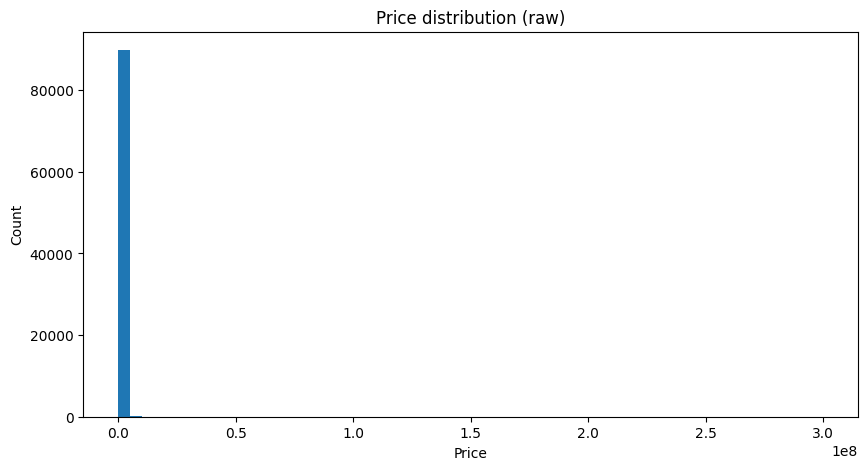

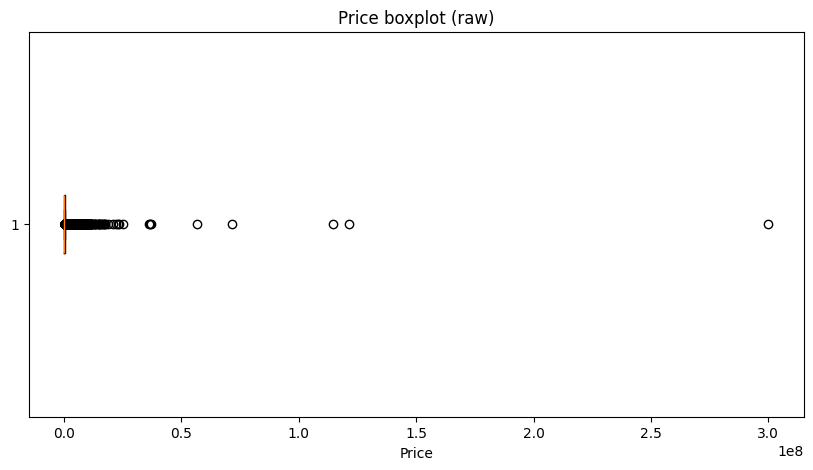

In [ ]:
plt.figure()
plt.hist(df["price"], bins=60)
plt.title("Price distribution (raw)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.boxplot(df["price"], vert=False)
plt.title("Price boxplot (raw)")
plt.xlabel("Price")
plt.show()

### Concept
IQR - Outliers affect summary stats and models.
We quantify outliers using IQR, and optionally cap extreme values (winsorization).


In [ ]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3-q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
print("IQR bounds:", lower, upper)

outliers = df[(df["price"]<lower) | (df["price"]>upper)]
print("Outlier rows:", outliers.shape[0])

# Save current display options
original_float_format = pd.get_option('display.float_format')

# Set display options for comma separation and no scientific notation
pd.set_option('display.float_format', '{:,.0f}'.format) # Using 0 decimal places for price values

# Display the descriptive statistics for outliers
display(outliers["price"].describe())

# Restore original display options
pd.set_option('display.float_format', original_float_format)

IQR bounds: -149000.0 675000.0
Outlier rows: 5077


,price
count,"5,077"
mean,"1,405,316"
std,"5,251,646"
min,"675,500"
25%,"750,000"
50%,"870,000"
75%,"1,175,000"
max,"300,000,000"


### Winsorization

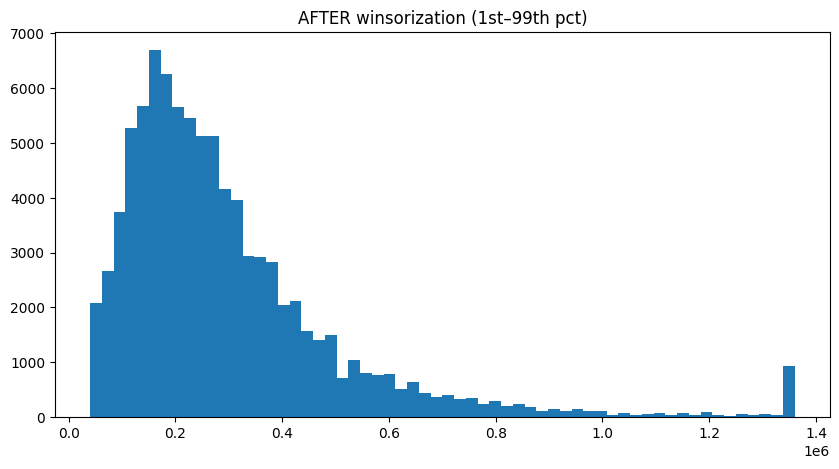

In [ ]:
p01 = df["price"].quantile(0.01)
p99 = df["price"].quantile(0.99)


df["price_winsor"] = df["price"].clip(p01, p99)

plt.hist(df["price_winsor"], bins=60)
plt.title("AFTER winsorization (1st–99th pct)")
plt.show()

## 9) Feature Engineering Step 1 — Log Transform (Before vs After)

### Concept
Price is usually right-skewed. Log transform makes the target more Gaussian-like for modeling.


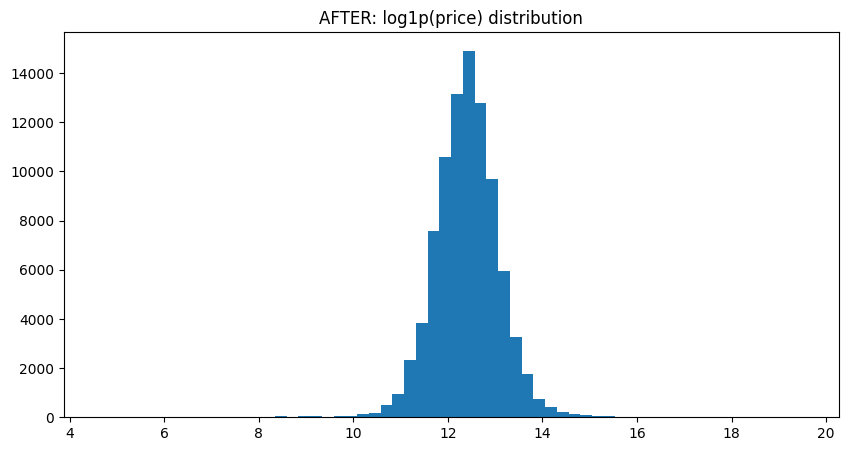

In [ ]:
df["log_price"] = np.log1p(df["price"])

plt.hist(df["log_price"], bins=60)
plt.title("AFTER: log1p(price) distribution")
plt.show()

### Concept
Dates are strings until we parse them into datetime.
Once parsed, we can extract time-based features useful for modeling and trends.
We also apply **cyclical encoding** for month/day-of-week because they repeat in cycles.


In [ ]:
print("BEFORE dtype:", df["date"].dtype)
df["date"].head()

BEFORE dtype: datetime64[ns]


,date
0,2015-01-02
1,2015-01-02
2,2015-01-02
3,2015-01-02
4,2015-01-05


In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True).dt.tz_convert(None)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["years_since_2015"] = df["year"] - 2015

# cyclical encodings
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
df["dow_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

print("AFTER dtype:", df["date"].dtype)
df[["date","year","month","quarter","day_of_week","is_weekend","month_sin","month_cos","dow_sin","dow_cos"]].head()

AFTER dtype: datetime64[ns]


,date,year,month,quarter,day_of_week,is_weekend,month_sin,month_cos,dow_sin,dow_cos
0,2015-01-02,2015,1,1,4,0,0.5,0.866025,-0.433884,-0.900969
1,2015-01-02,2015,1,1,4,0,0.5,0.866025,-0.433884,-0.900969
2,2015-01-02,2015,1,1,4,0,0.5,0.866025,-0.433884,-0.900969
3,2015-01-02,2015,1,1,4,0,0.5,0.866025,-0.433884,-0.900969
4,2015-01-05,2015,1,1,0,0,0.5,0.866025,0.000000,1.000000


### Concept
Median is robust to outliers; mean is affected by luxury properties.
We plot both to tell a market story.


In [ ]:
df["year_month"] = df["date"].dt.to_period("M").astype(str)
monthly = df.groupby("year_month")["price"].agg(["count","mean","median"]).reset_index()
monthly.head()

,year_month,count,mean,median
0,2015-01,537,260860.588454,204400.0
1,2015-02,576,256160.260417,188225.0
2,2015-03,657,233920.305936,193000.0
3,2015-04,671,254781.214605,200000.0
4,2015-05,767,246332.319426,190000.0


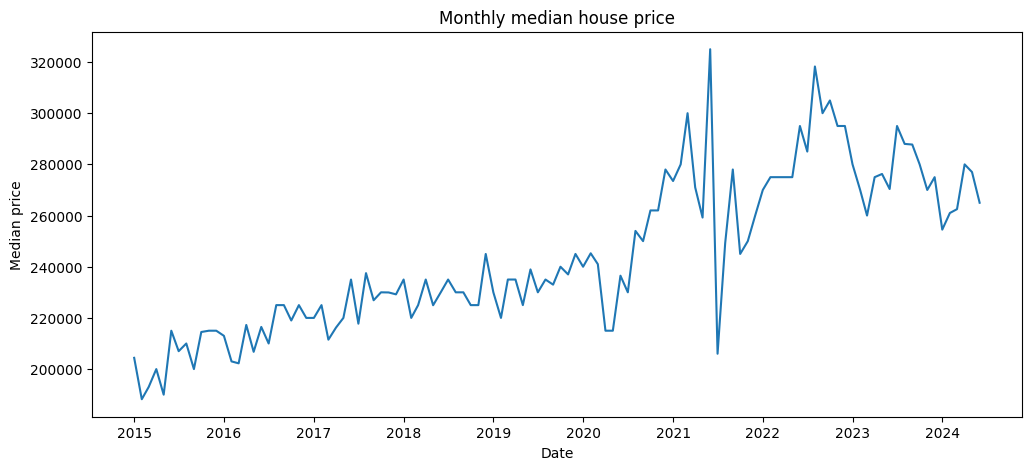

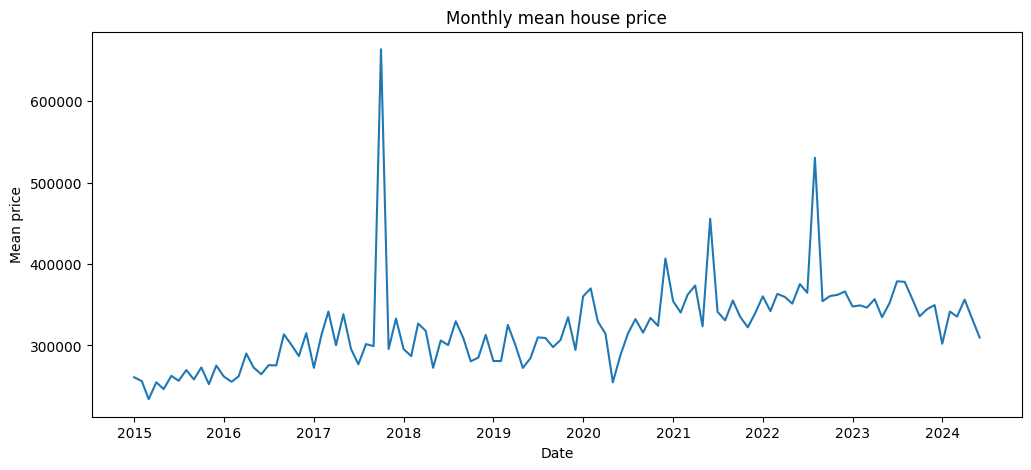

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(pd.to_datetime(monthly["year_month"]), monthly["median"])
plt.title("Monthly median house price")
plt.xlabel("Date")
plt.ylabel("Median price")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(pd.to_datetime(monthly["year_month"]), monthly["mean"])
plt.title("Monthly mean house price")
plt.xlabel("Date")
plt.ylabel("Mean price")
plt.show()

### Concept
We compare distributions of price across categories. We show both raw price and log_price.


In [ ]:
for col in ["property_type","new_build","freehold"]:
    print("\n===", col, "===")
    display(df[col].value_counts(dropna=False))


=== property_type ===


,count
property_type,
D,30434
S,26218
T,21374
F,7551
O,4380



=== new_build ===


,count
new_build,
N,78855
Y,11102



=== freehold ===


,count
freehold,
F,76973
L,12984


/tmp/ipython-input-1120910430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


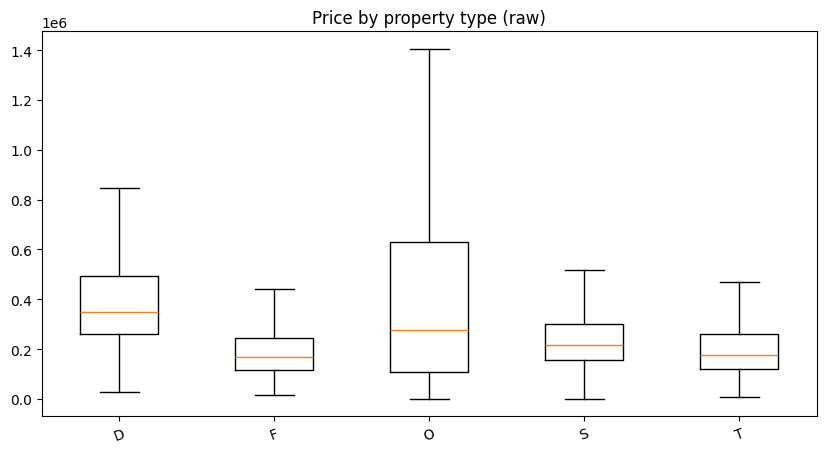

/tmp/ipython-input-1120910430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


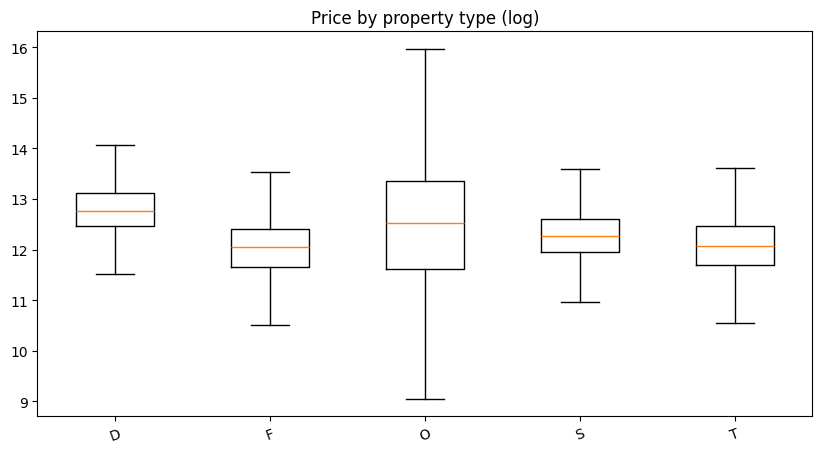

In [ ]:
def boxplot_by_category(data, cat_col, y_col="price", title=None):
    d = data[[cat_col, y_col]].dropna().copy()
    labels = sorted(d[cat_col].unique())
    groups = [d.loc[d[cat_col]==g, y_col].values for g in labels]
    plt.figure(figsize=(10,5))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title or f"{y_col} by {cat_col}")
    plt.xticks(rotation=20)
    plt.show()

boxplot_by_category(df, "property_type", "price", "Price by property type (raw)")
boxplot_by_category(df, "property_type", "log_price", "Price by property type (log)")


/tmp/ipython-input-1120910430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


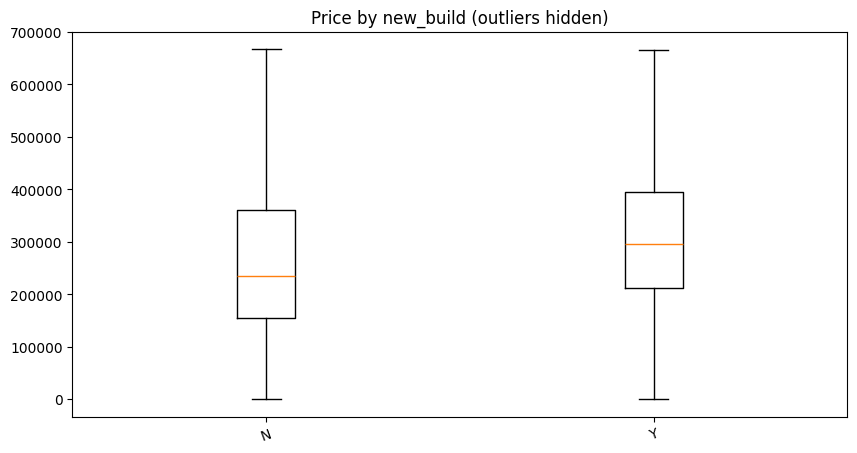

/tmp/ipython-input-1120910430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


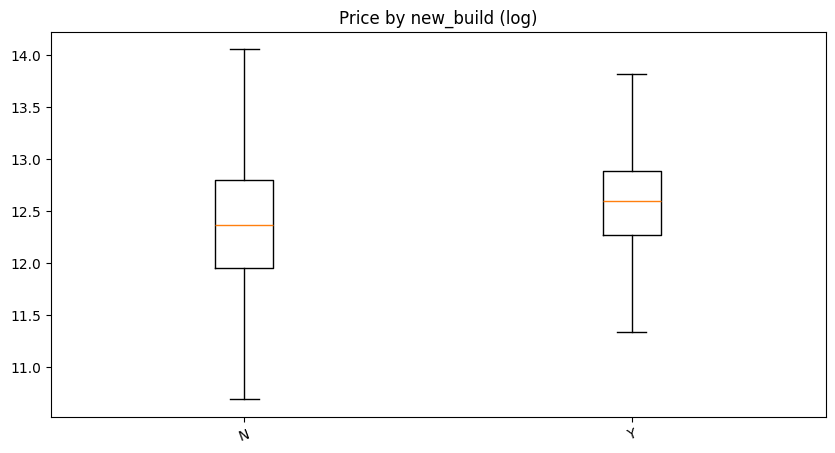

In [ ]:
boxplot_by_category(df, "new_build", "price", "Price by new_build (outliers hidden)")
boxplot_by_category(df, "new_build", "log_price", "Price by new_build (log)")

/tmp/ipython-input-1120910430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


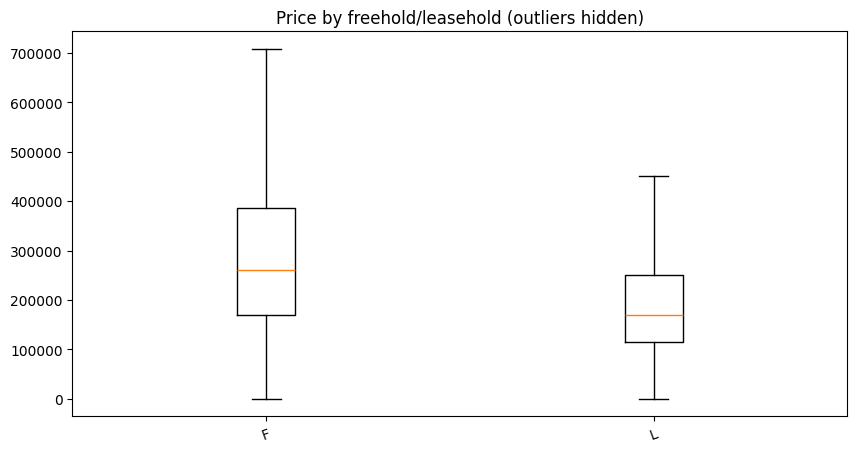

/tmp/ipython-input-1120910430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


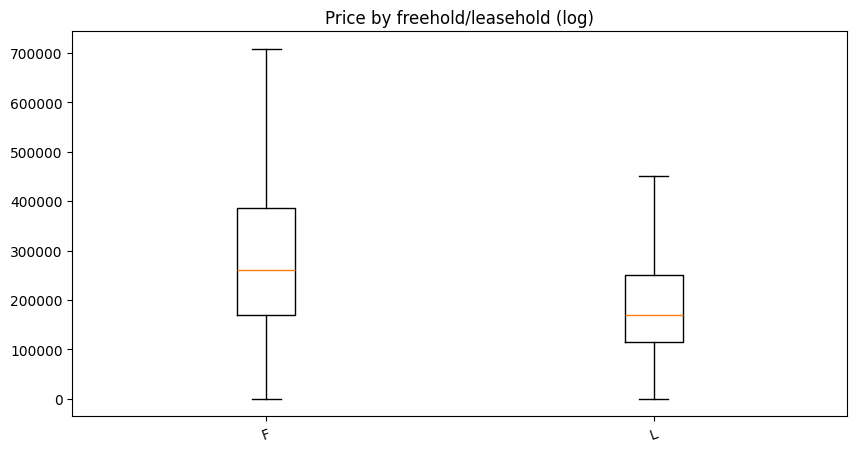

In [ ]:
boxplot_by_category(df, "freehold", "price", "Price by freehold/leasehold (outliers hidden)")
boxplot_by_category(df, "freehold", "price", "Price by freehold/leasehold (log)")

### Concept
Full postcodes are too granular. We extract area/district for modeling.


In [ ]:
df[["postcode"]].head(5)

,postcode
0,TN21 9HJ
1,NG23 7LD
2,L37 3NU
3,NG17 7EH
4,SY4 1HA


In [ ]:
df["postcode_clean"] = df["postcode"].astype(str).str.upper().str.replace(r"\s+", "", regex=True)
df["postcode_area"] = df["postcode_clean"].str.extract(r"^([A-Z]{1,2})", expand=False)
df["postcode_district"] = df["postcode_clean"].str.extract(r"^([A-Z]{1,2}\d{1,2})", expand=False)

df[["postcode","postcode_area","postcode_district"]].head(10)

,postcode,postcode_area,postcode_district
0,TN21 9HJ,TN,TN21
1,NG23 7LD,NG,NG23
2,L37 3NU,L,L37
3,NG17 7EH,NG,NG17
4,SY4 1HA,SY,SY41
5,CW5 6PU,CW,CW56
6,B96 6DW,B,B96
7,CM14 5LQ,CM,CM14
8,CB6 1NX,CB,CB61
9,DH7 6AU,DH,DH76


In [ ]:
df[["county","district","town", "postcode_area", "postcode_district"]].head()

,county,district,town,postcode_area,postcode_district
0,EAST SUSSEX,WEALDEN,HEATHFIELD,TN,TN21
1,NOTTINGHAMSHIRE,NEWARK AND SHERWOOD,NEWARK,NG,NG23
2,MERSEYSIDE,SEFTON,LIVERPOOL,L,L37
3,NOTTINGHAMSHIRE,ASHFIELD,NOTTINGHAM,NG,NG17
4,SHROPSHIRE,SHROPSHIRE,SHREWSBURY,SY,SY41


### Concept
In housing, prices change over time. Random splitting leaks future info.
We split by year: Train ≤ cutoff_year, Test > cutoff_year.


In [ ]:
df = df.sort_values("date").reset_index(drop=True)

cutoff_year = 2022
train_df = df[df["year"] <= cutoff_year].copy()
test_df  = df[df["year"] > cutoff_year].copy()

print("Train years:", train_df["year"].min(), "-", train_df["year"].max(), "Rows:", train_df.shape[0])
print("Test years :", test_df["year"].min(), "-", test_df["year"].max(), "Rows:", test_df.shape[0])

Train years: 2015 - 2022 Rows: 81467
Test years : 2023 - 2024 Rows: 8490


### Concept
Rare categories create noise. We learn rare groups from TRAIN only and apply to TEST.


In [ ]:
def group_rare(train_series, test_series, min_count=50):
    counts = train_series.value_counts()
    rare = counts[counts < min_count].index
    return train_series.replace(rare, "OTHER"), test_series.replace(rare, "OTHER")

high_card = ["town","district","county","street","postcode_area","postcode_district"]

print("BEFORE rare-grouping unique counts (train):")
for col in high_card:
    print(col, train_df[col].nunique(dropna=False))

BEFORE rare-grouping unique counts (train):
town 956
district 359
county 117
street 40684
postcode_area 106
postcode_district 3050


In [ ]:
for col in high_card:
    train_df[col], test_df[col] = group_rare(train_df[col].astype(str), test_df[col].astype(str), min_count=50)

print("AFTER rare-grouping unique counts (train):")
for col in high_card:
    print(col, train_df[col].nunique(dropna=False))

AFTER rare-grouping unique counts (train):
town 338
district 312
county 108
street 39
postcode_area 99
postcode_district 474


### Concept
Frequency encoding uses train frequencies and maps them onto both train and test.


In [ ]:
def frequency_encode(train_series, test_series):
    freq = train_series.value_counts()
    return train_series.map(freq).fillna(0).astype(int), test_series.map(freq).fillna(0).astype(int)

freq_cols = high_card
print("BEFORE: sample categories")
train_df[freq_cols].head(3)

BEFORE: sample categories


,town,district,county,street,postcode_area,postcode_district
0,OTHER,WEALDEN,EAST SUSSEX,OTHER,TN,OTHER
1,NEWARK,NEWARK AND SHERWOOD,NOTTINGHAMSHIRE,OTHER,NG,NG23
2,LIVERPOOL,SEFTON,MERSEYSIDE,OTHER,L,L37


### Example

In [ ]:
# Count 'OTHER' in the 'town' column after rare-grouping
other_town_count = train_df['town'].value_counts().get('OTHER', 0)
print(f"'OTHER' appeared {other_town_count} times in the 'town' column after rare-grouping.")

# Get the frequency encoding value for 'OTHER' in the 'town_freq' column
# We need to find the original count that 'OTHER' maps to.
# This value is derived from the 'freq' series calculated in frequency_encode
# and applied to the 'town' column where values were replaced with 'OTHER'.
# So, 'OTHER' in town_freq will have the count of all original rare values combined.
# A more direct way is to check the frequency map for 'OTHER' if 'OTHER' is explicitly mapped.

# Re-calculate frequency map for 'town' to get the freq value for 'OTHER'
freq_map_town = train_df['town'].value_counts()
other_town_freq_value = freq_map_town.get('OTHER', 0)
print(f"The frequency encoded value for 'OTHER' in 'town_freq' will be: {other_town_freq_value}")

freq_map_district = train_df['district'].value_counts()
wealden_district_freq_value = freq_map_district.get('WEALDEN', 0)
print(f"Similarly, The frequency encoded value for 'WEALDEN' in 'district_freq' will be : {wealden_district_freq_value}")


'OTHER' appeared 10404 times in the 'town' column after rare-grouping.
The frequency encoded value for 'OTHER' in 'town_freq' will be: 10404
Similarly, The frequency encoded value for 'WEALDEN' in 'district_freq' will be : 240


In [ ]:
for col in freq_cols:
    train_df[f"{col}_freq"], test_df[f"{col}_freq"] = frequency_encode(train_df[col], test_df[col])

print("AFTER: sample freq features")
train_df[[f"{c}_freq" for c in freq_cols]].head(3)

AFTER: sample freq features


,town_freq,district_freq,county_freq,street_freq,postcode_area_freq,postcode_district_freq
0,10404,240,466,75590,1170,39626
1,263,364,2669,75590,3106,82
2,735,315,1268,75590,946,99


## Target Encoding (Train-only + Smoothing) — Before vs After

### Concept
Target encoding adds “typical price” per category. In production:
- compute means on train only
- apply mapping to test
- smooth with global mean


In [ ]:
def target_encode_train_only(train_df, test_df, col, target="log_price", smoothing=20):
    global_mean = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(["mean","count"])
    smooth = (stats["count"]*stats["mean"] + smoothing*global_mean) / (stats["count"] + smoothing)
    return train_df[col].map(smooth).fillna(global_mean), test_df[col].map(smooth).fillna(global_mean)

te_cols = ["county","district","town","postcode_area","postcode_district"]

print("BEFORE: sample categories for TE")
train_df[te_cols].head(3)

BEFORE: sample categories for TE


,county,district,town,postcode_area,postcode_district
0,EAST SUSSEX,WEALDEN,OTHER,TN,OTHER
1,NOTTINGHAMSHIRE,NEWARK AND SHERWOOD,NEWARK,NG,NG23
2,MERSEYSIDE,SEFTON,LIVERPOOL,L,L37


In [ ]:
for col in te_cols:
    train_df[f"{col}_te"], test_df[f"{col}_te"] = target_encode_train_only(train_df, test_df, col, target="log_price", smoothing=20)

print("AFTER: sample target-encoded features")
train_df[[f"{c}_te" for c in te_cols]].head(3)

AFTER: sample target-encoded features


,county_te,district_te,town_te,postcode_area_te,postcode_district_te
0,12.845143,12.842454,12.494493,12.834062,12.398578
1,12.190119,12.191515,12.248966,12.162743,12.500720
2,12.010057,12.205323,11.976218,12.041899,12.478047


## Feature Table Construction (Before vs After)

### Concept
We now assemble the final model feature table:
- engineered numeric features
- frequency encodings
- target encodings
- one-hot encoded small categorical features


In [ ]:
numeric_features = [
    "year","quarter","is_weekend","years_since_2015",
    "month_sin","month_cos","dow_sin","dow_cos"
] + [f"{c}_freq" for c in freq_cols] + [f"{c}_te" for c in te_cols]

cat_features = ["property_type","new_build","freehold"]

print("Numeric features:", len(numeric_features))
print("Categorical (one-hot) features:", cat_features)

Numeric features: 19
Categorical (one-hot) features: ['property_type', 'new_build', 'freehold']


In [ ]:
# BEFORE: raw columns preview
train_df[cat_features + numeric_features[:5]].head(2)

,property_type,new_build,freehold,year,quarter,is_weekend,years_since_2015,month_sin
0,S,N,F,2015,1,0,0,0.5
1,D,N,F,2015,1,0,0,0.5


In [ ]:
X_train_num = train_df[numeric_features].copy()
X_test_num  = test_df[numeric_features].copy()

# start of one-hot encoding for property_type , new_build , freehold

X_train_cat = pd.get_dummies(train_df[cat_features], drop_first=False)
X_test_cat  = pd.get_dummies(test_df[cat_features], drop_first=False)

# align
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join="left", axis=1, fill_value=0)

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test  = pd.concat([X_test_num, X_test_cat], axis=1)

#end of one-hot encoding

y_train = train_df["log_price"].values
y_test  = test_df["log_price"].values



print("AFTER: feature table shapes - NOT 88 but 28 features - ******CORRECTION********")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

print("\n--- Sample X_train (first 3 rows) ---")
display(X_train.head(3))

print("\n--- Sample y_train (first 3 elements) ---")
print(y_train[:3])

print("\n--- Sample X_test (first 3 rows) ---")
display(X_test.head(3))

print("\n--- Sample y_test (first 3 elements) ---")
print(y_test[:3])

AFTER: feature table shapes - NOT 88 but 28 features - ******CORRECTION********
X_train: (81467, 28) X_test: (8490, 28)

--- Sample X_train (first 3 rows) ---


,year,quarter,is_weekend,years_since_2015,month_sin,month_cos,dow_sin,dow_cos,town_freq,district_freq,county_freq,street_freq,postcode_area_freq,postcode_district_freq,county_te,district_te,town_te,postcode_area_te,postcode_district_te,property_type_D,property_type_F,property_type_O,property_type_S,property_type_T,new_build_N,new_build_Y,freehold_F,freehold_L
0,2015,1,0,0,0.5,0.866025,-0.433884,-0.900969,10404,240,466,75590,1170,39626,12.845143,12.842454,12.494493,12.834062,12.398578,False,False,False,True,False,True,False,True,False
1,2015,1,0,0,0.5,0.866025,-0.433884,-0.900969,263,364,2669,75590,3106,82,12.190119,12.191515,12.248966,12.162743,12.500720,True,False,False,False,False,True,False,True,False
2,2015,1,0,0,0.5,0.866025,-0.433884,-0.900969,735,315,1268,75590,946,99,12.010057,12.205323,11.976218,12.041899,12.478047,True,False,False,False,False,True,False,False,True



--- Sample y_train (first 3 elements) ---
[12.6443308  12.36734505 12.81584093]

--- Sample X_test (first 3 rows) ---


,year,quarter,is_weekend,years_since_2015,month_sin,month_cos,dow_sin,dow_cos,town_freq,district_freq,county_freq,street_freq,postcode_area_freq,postcode_district_freq,county_te,district_te,town_te,postcode_area_te,postcode_district_te,property_type_D,property_type_F,property_type_O,property_type_S,property_type_T,new_build_N,new_build_Y,freehold_F,freehold_L
81467,2023,1,0,8,0.5,0.866025,0.781831,0.62349,978,541,2340,0,2019,163,12.137085,12.294528,12.228462,12.235884,12.006225,False,False,False,False,True,True,False,True,False
81468,2023,1,0,8,0.5,0.866025,0.781831,0.62349,2179,503,4762,0,2191,144,12.082106,12.110845,12.029340,12.030819,12.273091,True,False,False,False,False,True,False,False,True
81469,2023,1,0,8,0.5,0.866025,0.781831,0.62349,446,178,178,75590,612,116,11.916201,11.916201,12.081475,12.161270,12.070175,True,False,False,False,False,True,False,True,False



--- Sample y_test (first 3 elements) ---
[11.6526961  12.86100121 12.57763965]


# Multivariate Analysis — Correlation Structure

At this stage, all features are numeric and ready for modeling.

Before training the model, we examine:

- Correlation between engineered features
- Correlation with the target variable (log_price)
- Potential multicollinearity
- Feature redundancy

This helps us understand:
- Which features carry strong signal
- Whether some features are highly correlated with each other
- Whether regularization (Ridge) is justified

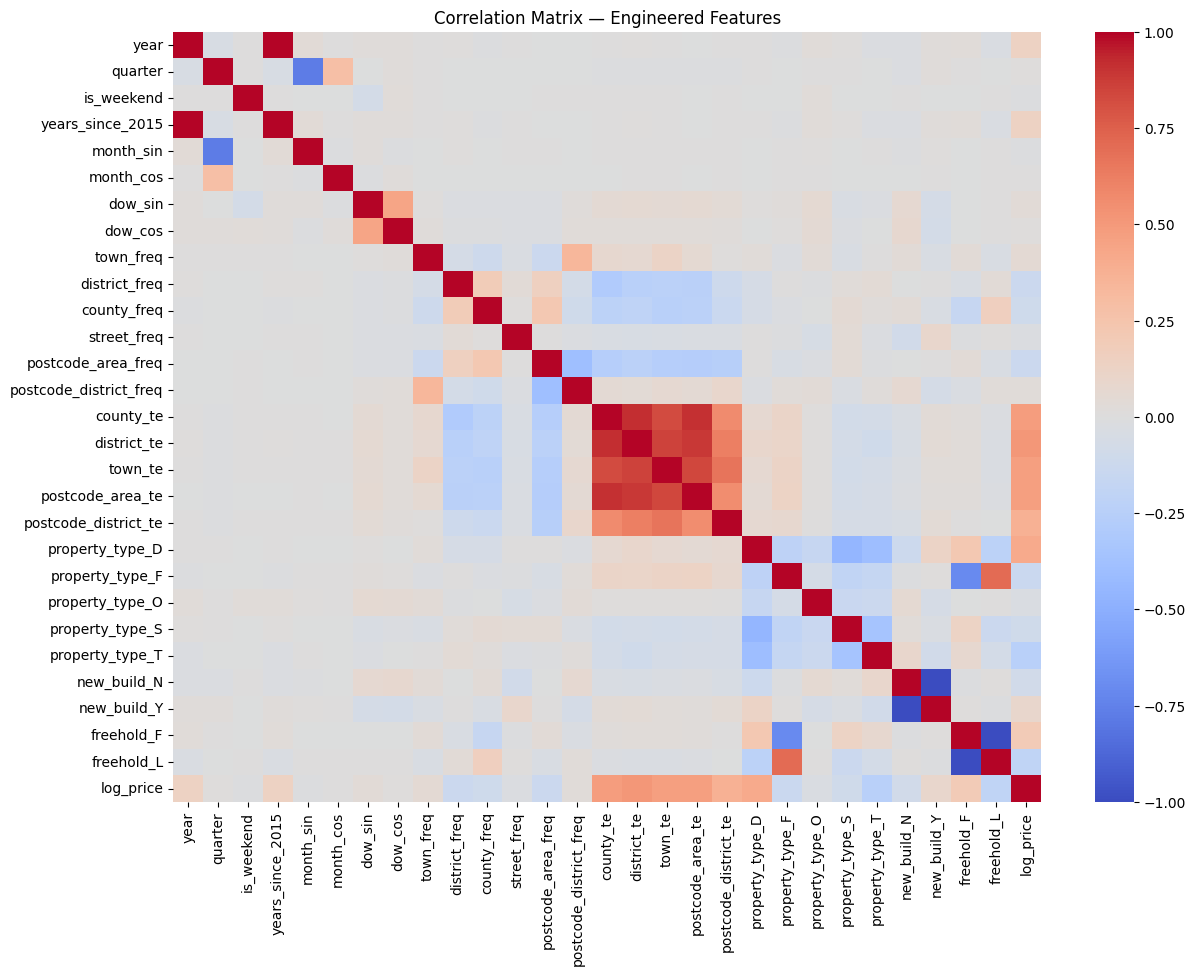

In [ ]:
# Combine X_train and target for correlation analysis
train_corr_df = X_train.copy()
train_corr_df["log_price"] = y_train

# Compute correlation matrix
corr_matrix = train_corr_df.corr()

# Plot full heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Engineered Features")
plt.show()

Top Correlations with Target

In [ ]:
# Correlation with target
target_corr = corr_matrix["log_price"].sort_values(ascending=False)

print("Top Positive Correlations with log_price:")
print(target_corr.head(10))

print("\nTop Negative Correlations with log_price:")
print(target_corr.tail(10))

Top Positive Correlations with log_price:
log_price               1.000000
district_te             0.514497
county_te               0.476968
town_te                 0.470577
postcode_area_te        0.469407
property_type_D         0.406390
postcode_district_te    0.368154
freehold_F              0.201643
years_since_2015        0.138851
year                    0.138851
Name: log_price, dtype: float64

Top Negative Correlations with log_price:
street_freq          -0.022229
property_type_O      -0.030989
new_build_N          -0.090590
property_type_S      -0.094574
county_freq          -0.102082
district_freq        -0.125514
postcode_area_freq   -0.126356
property_type_F      -0.139380
freehold_L           -0.201643
property_type_T      -0.245887
Name: log_price, dtype: float64


Reduced Heatmap (Top 15 Most Correlated with Target)

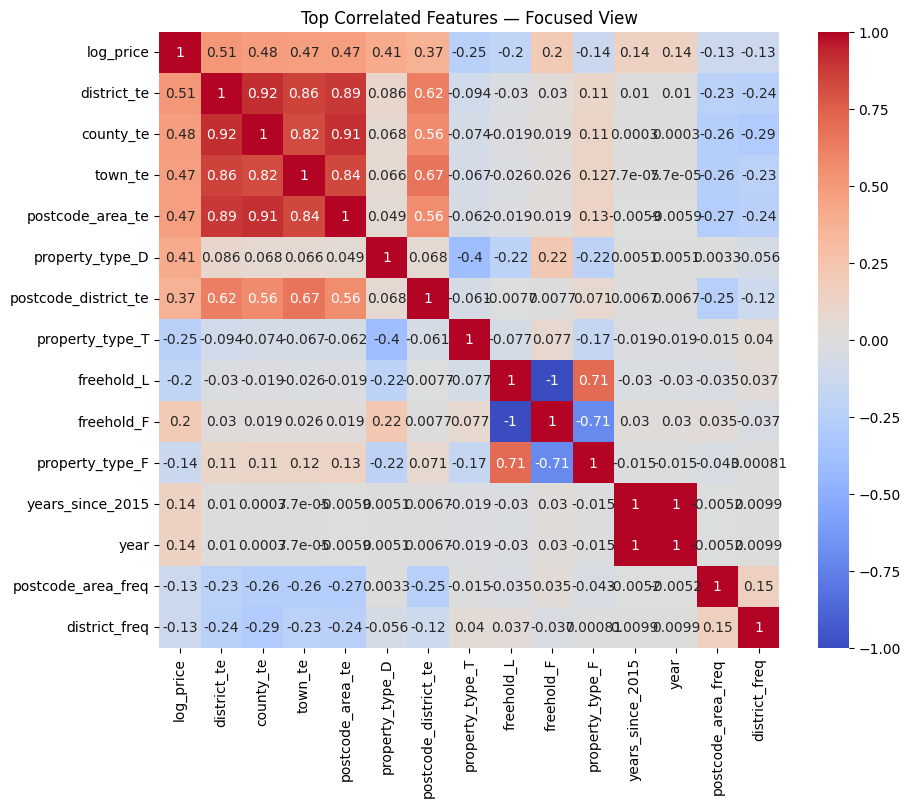

In [ ]:
# Select top correlated features with log_price (absolute)
top_features = target_corr.abs().sort_values(ascending=False).head(15).index

corr_top = corr_matrix.loc[top_features, top_features]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, cmap="coolwarm", center=0)
plt.title("Top Correlated Features — Focused View")
plt.show()

## Modeling (Scaling + Ridge) — Production-Safe Evaluation.  

#### This video is not about Linear Regression and wont cover Feature scaling , overfitting and Regularisation using Ridge Regression. Watch my other video to understand the Linear Regression Modelling, The link to the video : https://www.youtube.com/watch?v=RpvsKnOzKSw&t=147s

### Concept
Scaling is critical for linear models. We:
- fit scaler on train only
- transform test using same scaler
- evaluate in both log space and £ space


#This video is not about Linear Regression and wont cover Feature scaling , overfitting and Regularisation using Ridge Regression. Watch my other video to understand the Linear Regression Modelling, The link to the video : https://www.youtube.com/watch?v=RpvsKnOzKSw&t=147s

In [ ]:
scaler = StandardScaler()

#print("BEFORE SCALING: X_train (first 3 rows)")
#display(pd.DataFrame(X_train).head(3))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#print("\nAFTER SCALING: X_train_scaled (first 3 rows)")
#display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head(3))

#print("\nBEFORE SCALING: X_test (first 3 rows)")
#display(pd.DataFrame(X_test).head(3))

#print("\nAFTER SCALING: X_test_scaled (first 3 rows)")
#display(pd.DataFrame(X_test_scaled, columns=X_test.columns).head(3))

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

pred_log = model.predict(X_test_scaled)

mae_log = mean_absolute_error(y_test, pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))

print("\n✅ Test Metrics (log space)")
print("MAE:", mae_log)
print("RMSE:", rmse_log)

pred_price = np.expm1(pred_log)
true_price = np.expm1(y_test)

print("True Price:", true_price)
print("Predicted Price (£):", pred_price)

mae_price = mean_absolute_error(true_price, pred_price)
rmse_price = np.sqrt(mean_squared_error(true_price, pred_price))

print("\n✅ Test Metrics (£ space)")
print("MAE (£):", mae_price)
print("RMSE (£):", rmse_price)


✅ Test Metrics (log space)
MAE: 0.34902352698452815
RMSE: 0.5387812898208048
True Price: [115000. 385000. 290000. ... 420000. 830000. 465000.]
Predicted Price (£): [186884.74570866 281710.29126102 242255.24522331 ... 409573.44449062
 816436.78750407 424525.65257169]

✅ Test Metrics (£ space)
MAE (£): 122105.68811211002
RMSE (£): 303092.96050781023


In [ ]:
import pandas as pd
df_comparison = pd.DataFrame({
    'True Price': true_price,
    'Predicted Price': pred_price
})
display(df_comparison.head())

,True Price,Predicted Price
0,115000.0,186884.745709
1,385000.0,281710.291261
2,290000.0,242255.245223
3,200000.0,246424.833413
4,252500.0,343705.264246
